In [51]:
import numpy as np
import pandas as pd
import torch
from torch import nn
import xgboost as xgb

import math
from matplotlib import pyplot as plt

from func.load_mnist import load_mnist
from func.binarize_embeddings import binarize_embeddings

from Model_QuantizedAE import QuantizedAE

In [52]:
train_dl, validate_dl = load_mnist()

In [53]:

def plot_sample_predictions(samples, labels, predictions):
    n = len(samples)
    grid_size = math.isqrt(n)
    if grid_size * grid_size != n:
        raise ValueError(f"Number of samples must be a perfect square, got {n}")

    fig, axes = plt.subplots(grid_size, grid_size,
                             figsize=(grid_size * 1.8, grid_size * 2.0))

    for idx, ax in enumerate(axes.flat):
        ax.imshow(samples[idx].squeeze().numpy(), cmap="gray", interpolation="nearest")
        title = f"{predictions[idx]} "+("[✔]" if predictions[idx]==labels[idx] else "[✘]")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [54]:
def load_model(model:nn.Module):
  model_name = type(model).__name__
  state_dict = torch.load(f"data/model_weights/{model_name}.pnn", map_location="cpu")
  model.load_state_dict(state_dict)
  return model


In [55]:
model = load_model(
  QuantizedAE()
)
model_name = type(model).__name__

embedding_encoder = nn.Sequential(
  model.preprocess,
  model.features,
  nn.Flatten()
)

In [56]:
x , y = next(iter(validate_dl))
x = x[:8*8]
y = y[:8*8]

In [57]:
batch_embeddings = embedding_encoder(x).detach().numpy()
batch_embeddings = binarize_embeddings(batch_embeddings)
labels = y.detach().numpy()

In [58]:
# Load model and predict
booster = xgb.Booster()
booster.load_model("data/model_weights/xgb_decision_tree.json")

batch_embeddings_df = pd.DataFrame(
  batch_embeddings,
  columns=[f"e{i}" for i in range(batch_embeddings.shape[1])],
  dtype="category",
)

label_predictions = booster.predict(xgb.DMatrix(batch_embeddings_df, enable_categorical=True))
label_predictions = label_predictions.astype(np.int8)
label_predictions

array([3, 0, 1, 8, 2, 2, 1, 2, 8, 0, 6, 0, 8, 5, 3, 8, 1, 9, 0, 4, 6, 9,
       9, 7, 3, 0, 5, 5, 6, 3, 3, 0, 1, 6, 4, 4, 5, 1, 6, 3, 3, 8, 7, 7,
       7, 3, 8, 8, 4, 3, 6, 2, 5, 4, 9, 6, 0, 0, 2, 7, 0, 1, 7, 7],
      dtype=int8)

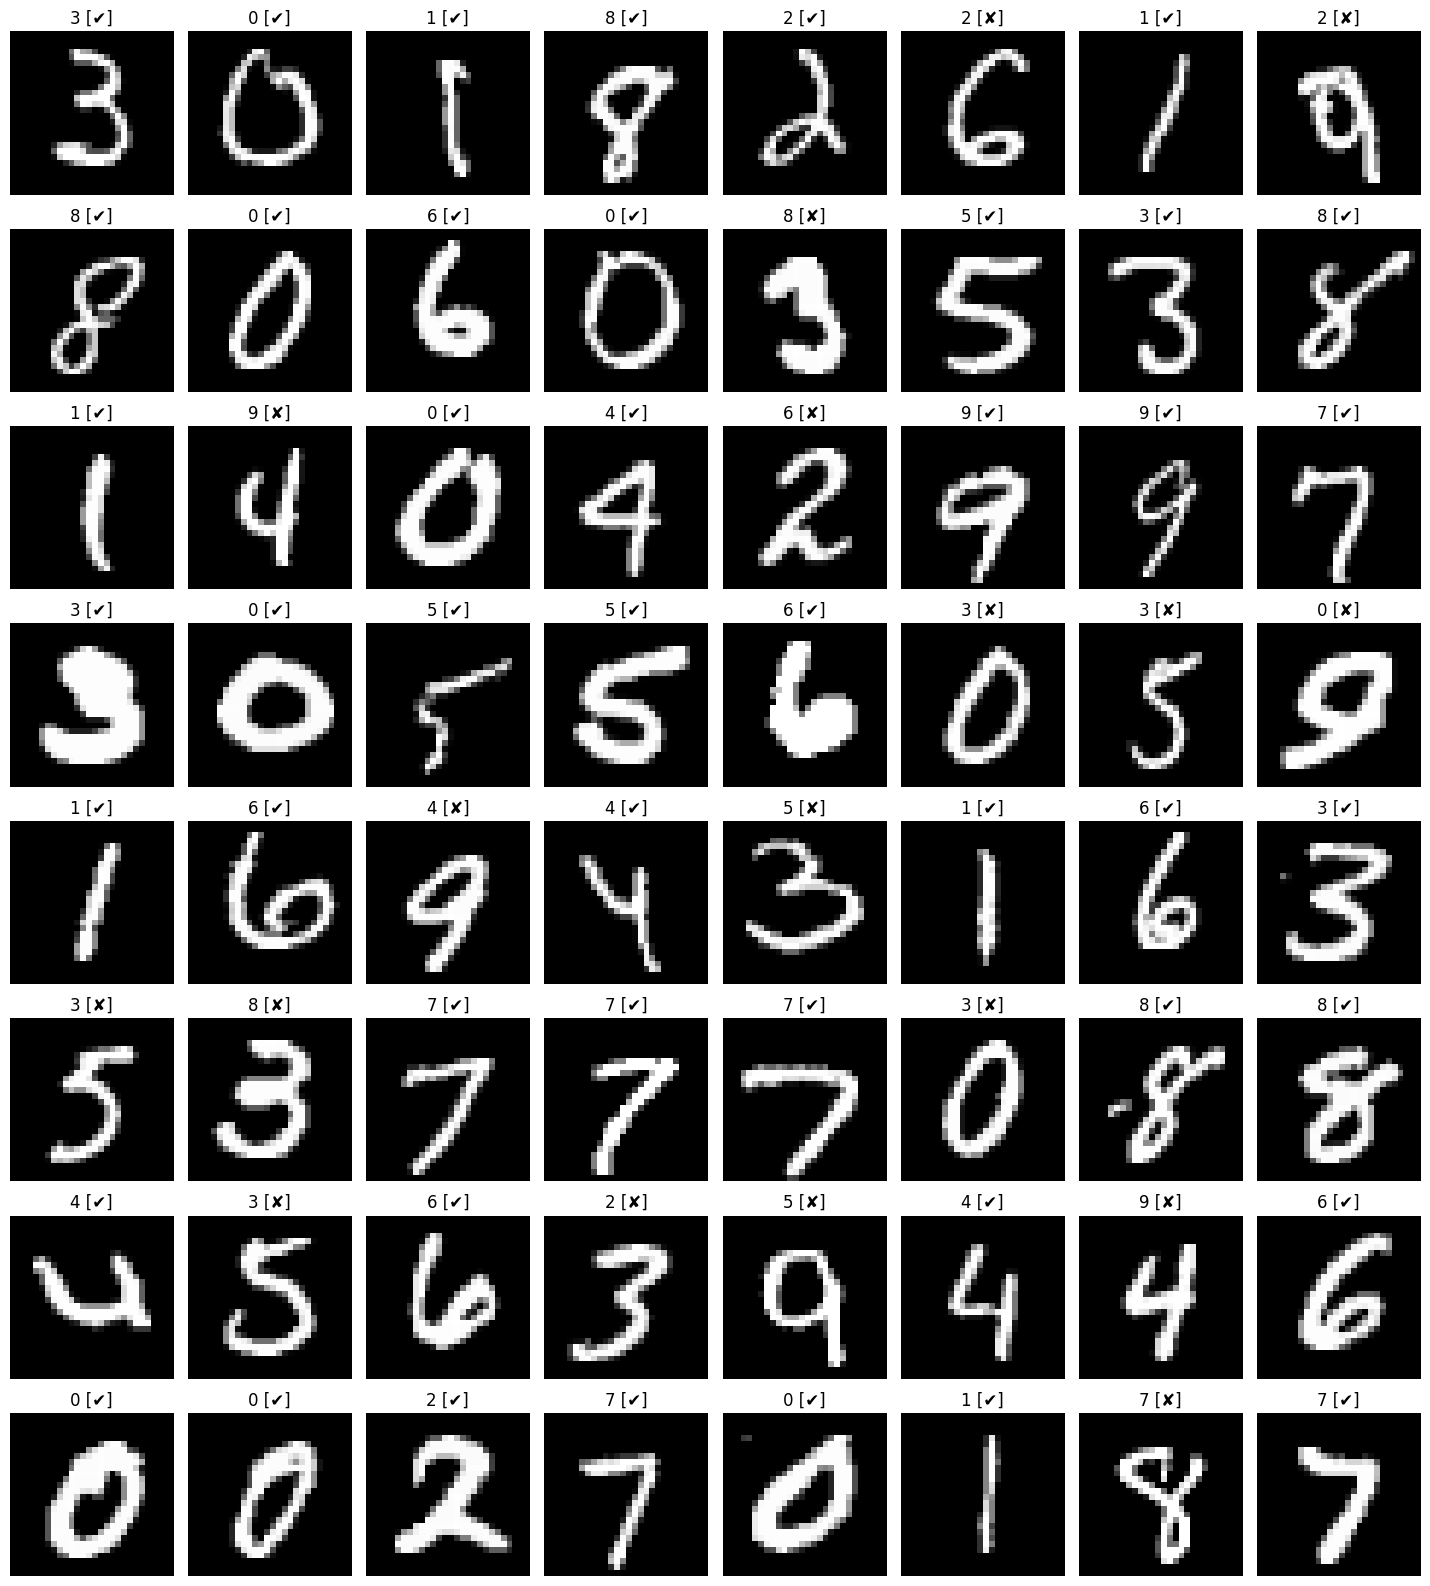

In [59]:
plot_sample_predictions(x,y,label_predictions)

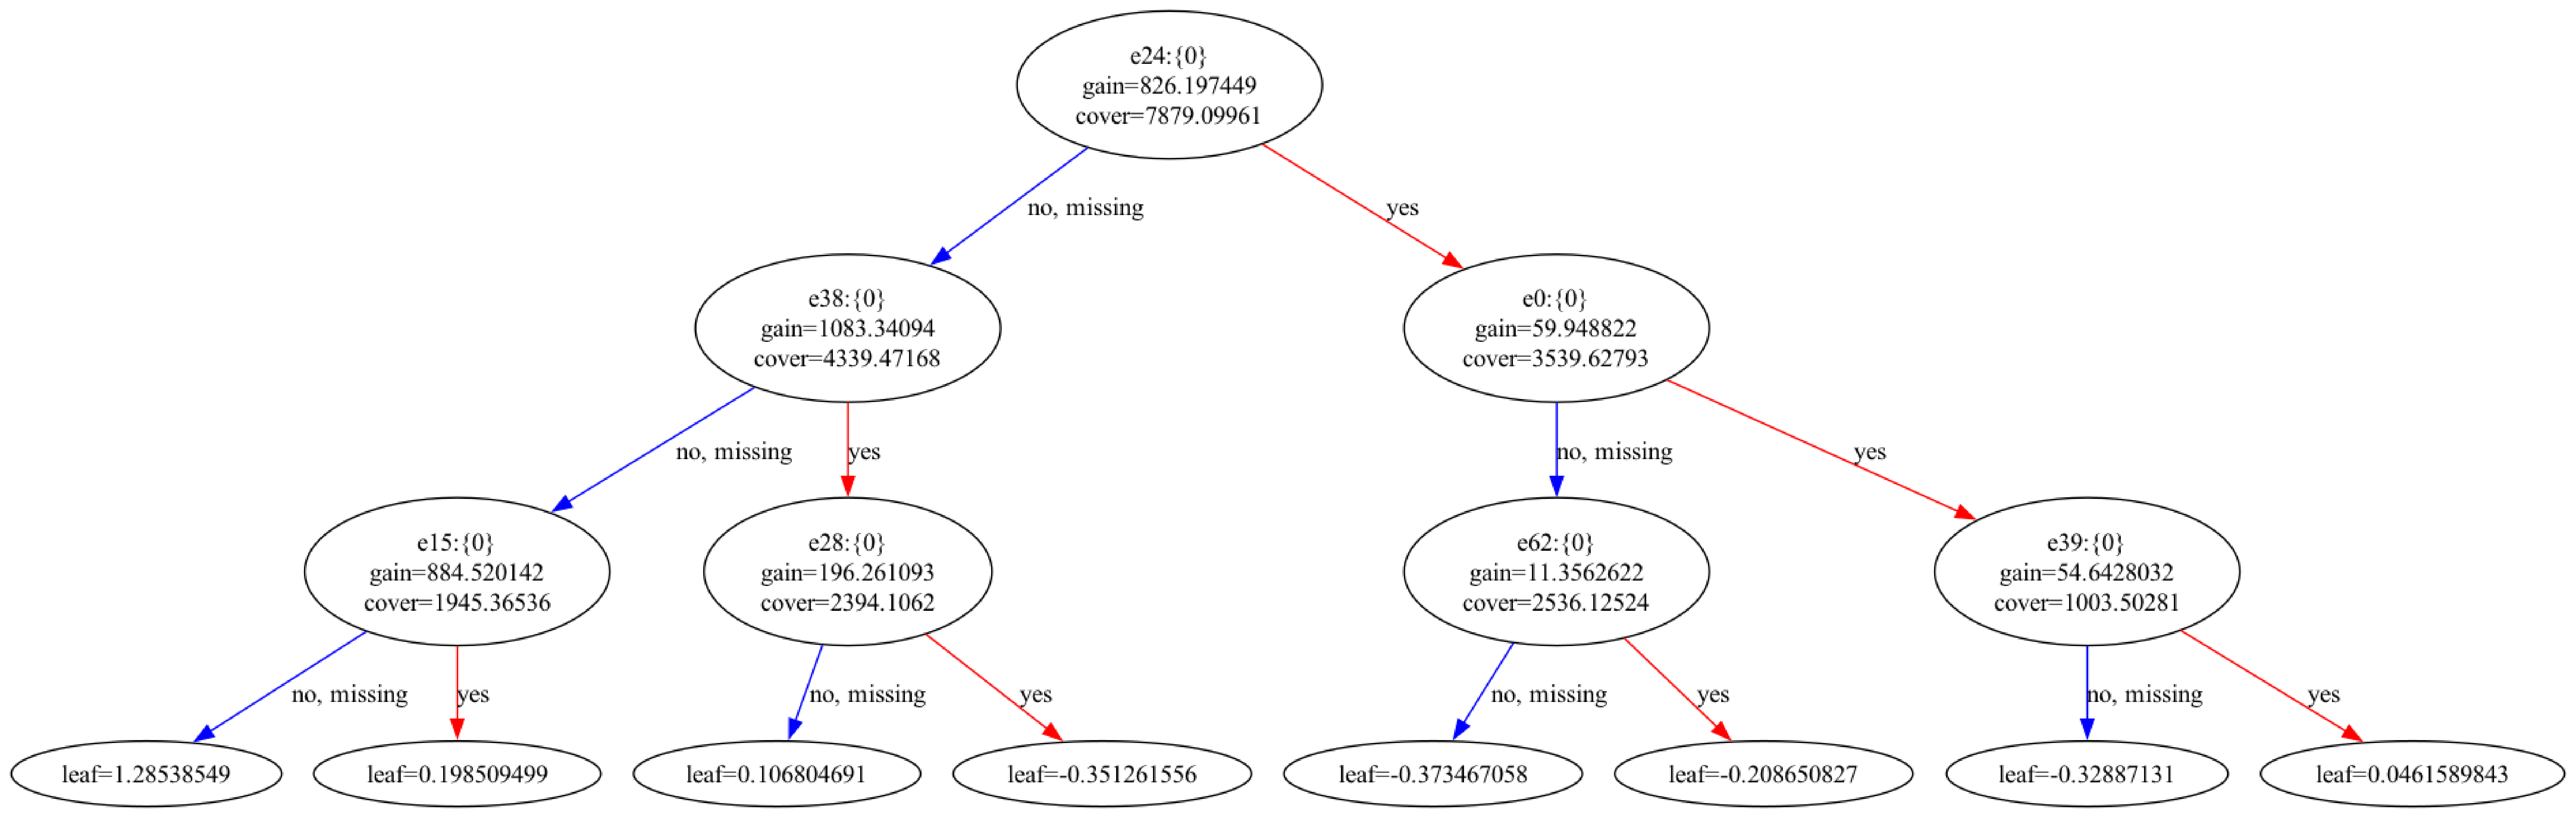

In [60]:
# Now we visualize the tree
fig, ax = plt.subplots(figsize=(80, 40))
xgb.plot_tree(booster, ax=ax, tree_idx=5)
plt.savefig("data/model_reports/xgb_decision_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [61]:
booster.dump_model('data/model_reports/xgb_decision_dump_trees.txt')

In [62]:
# Number of trees
booster.num_boosted_rounds()


10

In [70]:
print(labels[1])
batch_embeddings[1]

0


array([ 1, -1,  1, -1, -1, -1, -1, -1,  1, -1,  1, -1,  1, -1,  1,  1,  1,
       -1, -1,  1,  1,  1,  1, -1,  1,  1, -1,  1, -1, -1, -1, -1, -1,  1,
       -1,  1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1,  1,  1,  1,  1,  1,
       -1, -1,  1, -1,  1,  1,  1, -1, -1,  1, -1,  1, -1], dtype=int8)